# Experiment: 02 Layer Dynamics

Objective:
- Visualize how geometry signal changes with layer.
- Compare sparse layer sweeps with dense Qwen sweep to inspect bimodality.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

candidate_dirs = [Path.cwd(), Path.cwd() / "notebooks", *[parent / "notebooks" for parent in Path.cwd().parents]]
for candidate in candidate_dirs:
    if (candidate / "_viz_utils.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/_viz_utils.py from current working directory")

import matplotlib.pyplot as plt
import numpy as np

import _viz_utils as vu

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})


In [2]:
all_results = vu.load_all_results()
layer_rows = vu.collect_layer_rows(all_results)

def rows_for(model: str, dataset: str) -> list[dict]:
    selected = [r for r in layer_rows if r["model"] == model and r["dataset"] == dataset]
    return sorted(selected, key=lambda r: r["layer"])


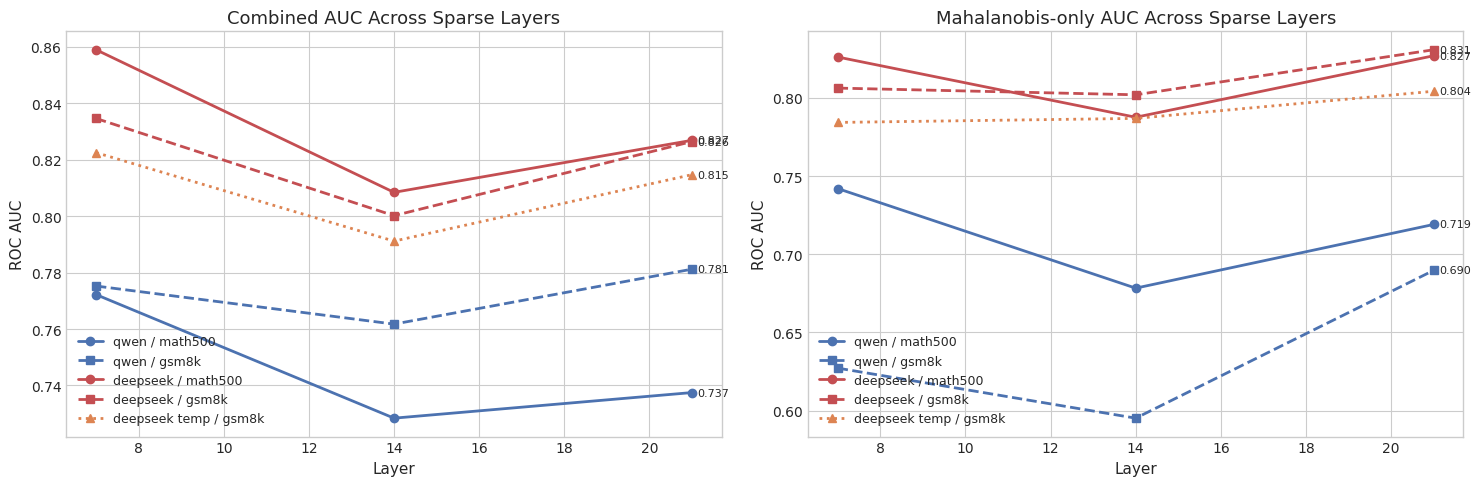

In [3]:
sparse_conditions = [
    ("qwen", "math500"),
    ("qwen", "gsm8k"),
    ("deepseek", "math500"),
    ("deepseek", "gsm8k"),
    ("deepseek_temp", "gsm8k"),
]

# Distinct styles so overlapping lines stay separable
styles = [
    ("#4C72B0", "-",  "o"),
    ("#4C72B0", "--", "s"),
    ("#C44E52", "-",  "o"),
    ("#C44E52", "--", "s"),
    ("#DD8452", ":",  "^"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for (model, dataset), (color, ls, marker) in zip(sparse_conditions, styles):
    rows = rows_for(model, dataset)
    if not rows:
        continue
    layers = [r["layer"] for r in rows]
    combined = [r["combined_auc"] for r in rows]
    mahal = [r["mahal_auc"] for r in rows]
    label = vu.condition_label(model, dataset)
    kw = dict(color=color, linestyle=ls, marker=marker, linewidth=2, markersize=6)
    axes[0].plot(layers, combined, label=label, **kw)
    axes[1].plot(layers, mahal, label=label, **kw)
    # Label endpoint value
    axes[0].annotate(f"{combined[-1]:.3f}", (layers[-1], combined[-1]),
                     xytext=(4, 0), textcoords="offset points", fontsize=8, va="center")
    axes[1].annotate(f"{mahal[-1]:.3f}", (layers[-1], mahal[-1]),
                     xytext=(4, 0), textcoords="offset points", fontsize=8, va="center")

for ax, title in zip(axes, ["Combined AUC Across Sparse Layers", "Mahalanobis-only AUC Across Sparse Layers"]):
    ax.set_title(title)
    ax.set_xlabel("Layer")
    ax.set_ylabel("ROC AUC")
    ax.legend(loc="lower left")

fig.tight_layout()
plt.show()


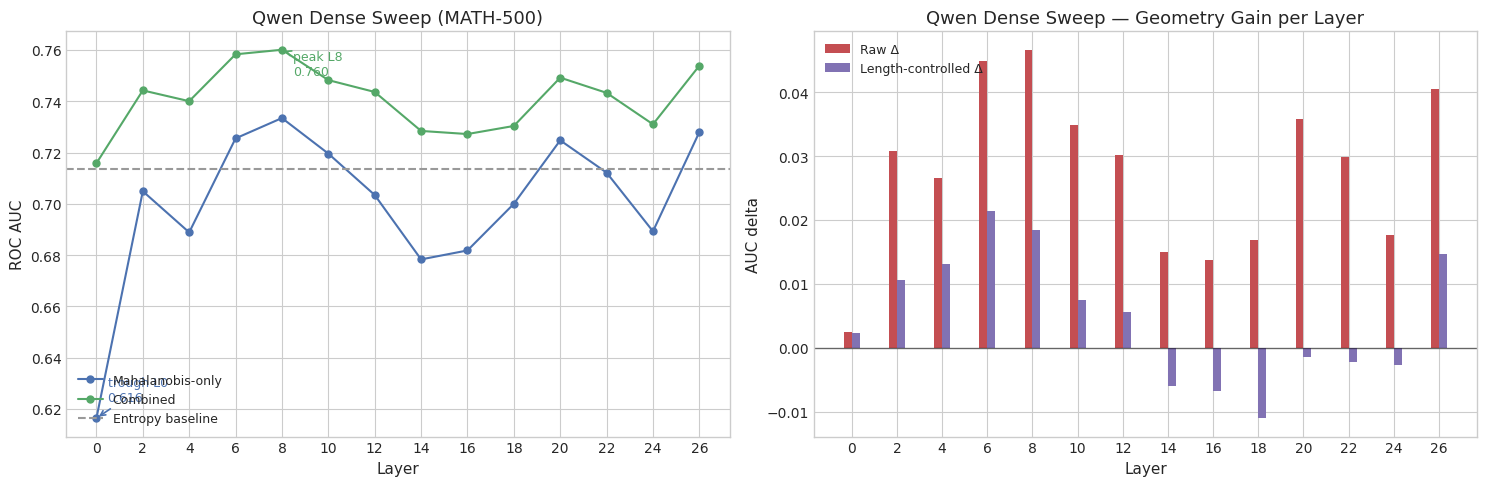

In [4]:
dense_rows = rows_for("qwen_dense", "math500")
layers = np.array([r["layer"] for r in dense_rows], dtype=int)
entropy = np.array([r["entropy_auc"] for r in dense_rows], dtype=float)
mahal = np.array([r["mahal_auc"] for r in dense_rows], dtype=float)
combined = np.array([r["combined_auc"] for r in dense_rows], dtype=float)
raw_delta = np.array([r["delta_raw"] for r in dense_rows], dtype=float)
len_delta = np.array([r["delta_len_ctrl"] for r in dense_rows], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(layers, mahal, marker="o", markersize=5, label="Mahalanobis-only", color="#4C72B0")
axes[0].plot(layers, combined, marker="o", markersize=5, label="Combined", color="#55A868")
axes[0].axhline(float(np.nanmean(entropy)), linestyle="--", color="#999999", label="Entropy baseline")

# Annotate best combined layer
best_idx = int(np.argmax(combined))
axes[0].annotate(
    f"peak L{layers[best_idx]}\n{combined[best_idx]:.3f}",
    (layers[best_idx], combined[best_idx]),
    xytext=(8, -18), textcoords="offset points",
    fontsize=9, color="#55A868",
    arrowprops=dict(arrowstyle="->", color="#55A868", lw=1.2),
)
# Annotate trough (L14 — weakest geometry layer)
trough_idx = int(np.argmin(mahal))
axes[0].annotate(
    f"trough L{layers[trough_idx]}\n{mahal[trough_idx]:.3f}",
    (layers[trough_idx], mahal[trough_idx]),
    xytext=(8, 12), textcoords="offset points",
    fontsize=9, color="#4C72B0",
    arrowprops=dict(arrowstyle="->", color="#4C72B0", lw=1.2),
)

axes[0].set_title("Qwen Dense Sweep (MATH-500)")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("ROC AUC")
axes[0].set_xticks(layers)
axes[0].legend(loc="lower left")

width = 0.35
axes[1].bar(layers - width / 2, raw_delta, width=width, label="Raw Δ", color="#C44E52")
axes[1].bar(layers + width / 2, len_delta, width=width, label="Length-controlled Δ", color="#8172B3")
axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.5)
axes[1].set_title("Qwen Dense Sweep — Geometry Gain per Layer")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("AUC delta")
axes[1].set_xticks(layers)
axes[1].legend(loc="upper left")

fig.tight_layout()
plt.show()


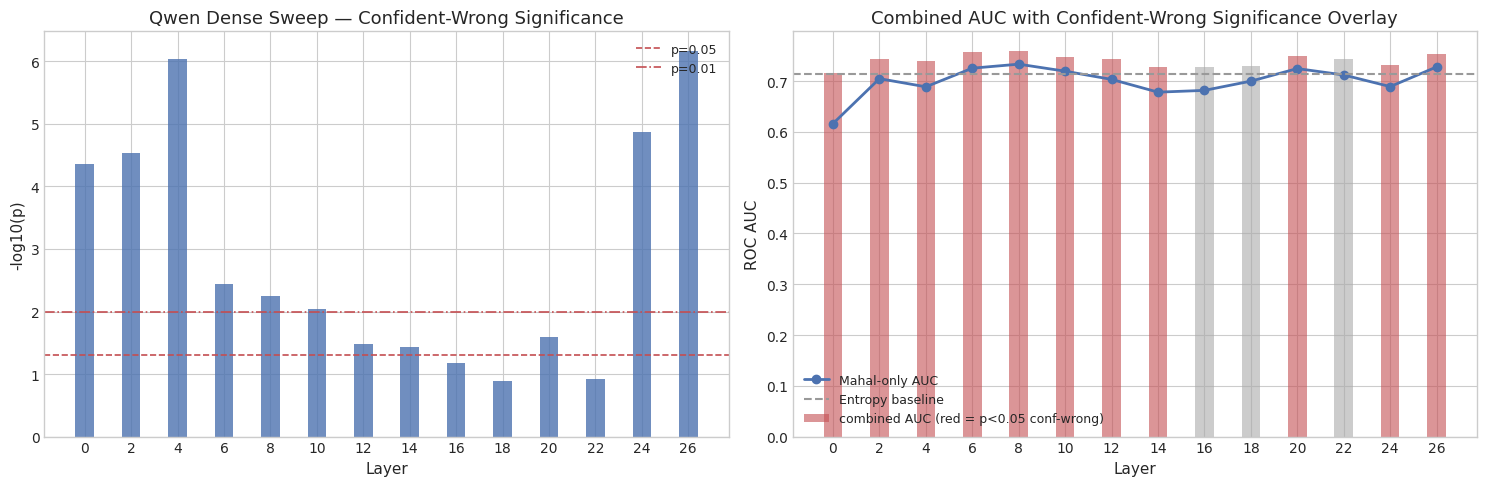

In [5]:
# Confident-wrong p-values across dense layers
# Mann-Whitney test on low-entropy tokens; significant p means geometry separates
# correct vs incorrect even at the model's most "confident" positions.
p_vals = np.array([r["confident_wrong_p"] for r in dense_rows])
layers_arr = np.array([r["layer"] for r in dense_rows])

# Replace zeros/NaN to avoid log issues
p_safe = np.where((p_vals > 0) & ~np.isnan(p_vals), p_vals, 1.0)
neg_log_p = -np.log10(p_safe)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: -log10(p) profile
axes[0].bar(layers_arr, neg_log_p, color="#4C72B0", alpha=0.8)
for thresh, label, ls in [(1.30, "p=0.05", "--"), (2.0, "p=0.01", "-.")]:
    axes[0].axhline(thresh, color="#C44E52", linestyle=ls, linewidth=1.2, label=label)
axes[0].set_title("Qwen Dense Sweep — Confident-Wrong Significance")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("-log10(p)")
axes[0].legend(loc="upper right")
axes[0].set_xticks(layers_arr)

# Right: overlay p-value significance on top of combined AUC curve
color_bars = ["#C44E52" if p < 0.05 else "#AAAAAA" for p in p_vals]
ax2 = axes[1]
ax2.bar(layers_arr, combined, color=color_bars, alpha=0.6, label="combined AUC (red = p<0.05 conf-wrong)")
ax2.plot(layers_arr, mahal, marker="o", color="#4C72B0", linewidth=2, label="Mahal-only AUC")
ax2.axhline(float(np.nanmean(entropy)), linestyle="--", color="#999999", label="Entropy baseline")
ax2.set_title("Combined AUC with Confident-Wrong Significance Overlay")
ax2.set_xlabel("Layer")
ax2.set_ylabel("ROC AUC")
ax2.legend(loc="lower left", fontsize=9)
ax2.set_xticks(layers_arr)

fig.tight_layout()
plt.show()
